# NanoGPT Internals: Seven Questions

Working directly against [karpathy/nanoGPT](https://github.com/karpathy/nanogpt) (cloned as a sibling
folder, imported below). Every step below runs real forward/backward passes on the actual
`GPT` model from `model.py` — nothing is simulated or hard-coded.

1. Print every tensor shape in a training step, and say what each dimension means.
2. Verify one gradient by hand (finite differences vs `backward()`).
3. Nudge a weight, measure the actual loss change, compare to what the gradient predicts.
4. Break gradient accumulation on purpose (average-of-averages over unequal micro-batches) and plot the gap.
5. Log the grad norm every step and find one step where it moved before the loss did.
6. Compute MFU honestly and say what's costing the distance to 40%.
7. Write out 0.1 bit-for-bit in fp32 / bf16 / fp8 E4M3, and say which one to train in.


In [1]:

import sys, os, copy, time, struct, math

import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('../nanogpt'))
from model import GPT, GPTConfig

torch.manual_seed(1337)

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
print(f"torch: {torch.__version__}")


device: mps
torch: 2.13.0


## Step 1 — Tensor shapes through one training step

A tiny GPT (2 layers, 4 heads, 64-dim embeddings, 256-token vocab) so the shapes are easy to
read. `B` = batch size, `T` = sequence length (block size), `C` = embedding dimension (`n_embd`),
`nh` = number of heads, `hs` = head size (`C // nh`), `V` = vocab size.


In [2]:

config = GPTConfig(block_size=64, vocab_size=256, n_layer=2, n_head=4, n_embd=64, dropout=0.0, bias=True)
model = GPT(config).to(device)

B, T = 2, 16
idx = torch.randint(0, config.vocab_size, (B, T), device=device)
targets = torch.randint(0, config.vocab_size, (B, T), device=device)

C, nh = config.n_embd, config.n_head
hs = C // nh
print(f"config: n_layer={config.n_layer} n_head={nh} n_embd={C} vocab_size={config.vocab_size} block_size={config.block_size}")
print(f"input : B={B} (batch size / independent sequences), T={T} (tokens per sequence)\n")

model.eval()
with torch.no_grad():
    tok_emb = model.transformer.wte(idx)
    print(f"tok_emb          {tuple(tok_emb.shape)}  -> (B, T, C): each of the B*T tokens becomes a length-{C} vector")

    pos = torch.arange(0, T, device=device).unsqueeze(0)
    pos_emb = model.transformer.wpe(pos)
    print(f"pos_emb          {tuple(pos_emb.shape)}  -> (1, T, C): one vector per position, broadcasts over the batch dim")

    x = model.transformer.drop(tok_emb + pos_emb)
    print(f"x (embed sum)    {tuple(x.shape)}  -> (B, T, C): token identity + position, added elementwise")

    block = model.transformer.h[0]
    x_ln = block.ln_1(x)
    print(f"ln_1(x)          {tuple(x_ln.shape)}  -> (B, T, C): normalized per-token, shape unchanged")

    qkv = block.attn.c_attn(x_ln)
    print(f"c_attn(x)        {tuple(qkv.shape)}  -> (B, T, 3C): Q,K,V for all heads, concatenated on the last dim")

    q, k, v = qkv.split(C, dim=2)
    q = q.view(B, T, nh, hs).transpose(1, 2)
    k = k.view(B, T, nh, hs).transpose(1, 2)
    v = v.view(B, T, nh, hs).transpose(1, 2)
    print(f"q,k,v (reshaped) {tuple(q.shape)}  -> (B, nh, T, hs): heads moved next to batch so attention is batched per head")

    att_scores = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(hs))
    print(f"q @ k^T          {tuple(att_scores.shape)}  -> (B, nh, T, T): attention score of every query token against every key token")

    y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
    print(f"attn output      {tuple(y.shape)}  -> (B, nh, T, hs): each head's weighted sum over values")

    y = y.transpose(1, 2).contiguous().view(B, T, C)
    print(f"heads merged     {tuple(y.shape)}  -> (B, T, C): heads concatenated back into one embedding per token")

    attn_out = block.attn.c_proj(y)
    print(f"c_proj(y)        {tuple(attn_out.shape)}  -> (B, T, C): output projection, mixes information across heads")

    x = x + attn_out
    print(f"x + attn         {tuple(x.shape)}  -> (B, T, C): residual stream, unchanged shape by design")

    x_ln2 = block.ln_2(x)
    h = block.mlp.c_fc(x_ln2)
    print(f"mlp.c_fc(x)      {tuple(h.shape)}  -> (B, T, 4C): MLP widens to 4x embedding dim")

    h = block.mlp.gelu(h)
    mlp_out = block.mlp.c_proj(h)
    print(f"mlp.c_proj(h)    {tuple(mlp_out.shape)}  -> (B, T, C): projected back down to embedding dim")

    x = x + mlp_out
    print(f"x + mlp          {tuple(x.shape)}  -> (B, T, C): residual stream after block 0 (block 1 repeats this pattern)")

    for blk in model.transformer.h[1:]:
        x = blk(x)
    x = model.transformer.ln_f(x)
    print(f"ln_f(x)          {tuple(x.shape)}  -> (B, T, C): final normalization before reading out logits")

    logits = model.lm_head(x)
    print(f"logits           {tuple(logits.shape)}  -> (B, T, V): a distribution over the {config.vocab_size}-token vocab, per position")

    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
    print(f"loss             {tuple(loss.shape)}  -> (): scalar, cross-entropy averaged over all B*T={B*T} predicted tokens")


number of parameters: 0.12M
config: n_layer=2 n_head=4 n_embd=64 vocab_size=256 block_size=64
input : B=2 (batch size / independent sequences), T=16 (tokens per sequence)

tok_emb          (2, 16, 64)  -> (B, T, C): each of the B*T tokens becomes a length-64 vector
pos_emb          (1, 16, 64)  -> (1, T, C): one vector per position, broadcasts over the batch dim
x (embed sum)    (2, 16, 64)  -> (B, T, C): token identity + position, added elementwise
ln_1(x)          (2, 16, 64)  -> (B, T, C): normalized per-token, shape unchanged
c_attn(x)        (2, 16, 192)  -> (B, T, 3C): Q,K,V for all heads, concatenated on the last dim
q,k,v (reshaped) (2, 4, 16, 16)  -> (B, nh, T, hs): heads moved next to batch so attention is batched per head
q @ k^T          (2, 4, 16, 16)  -> (B, nh, T, T): attention score of every query token against every key token
attn output      (2, 4, 16, 16)  -> (B, nh, T, hs): each head's weighted sum over values
heads merged     (2, 16, 64)  -> (B, T, C): heads concat

## Step 2 — Verify one gradient by hand

`backward()` gives an *analytic* gradient. A finite-difference (numerical) gradient gives an
independent estimate of the same quantity: `dL/dw ≈ (L(w+ε) − L(w−ε)) / 2ε`.

Two things matter for this to actually agree to several decimals:
- **Pick a weight that's used by every token**, not one embedding row that only fires for
  tokens that happen to appear in the batch (otherwise the numerical signal can be too small
  to detect above floating-point noise).
- **Use float64** for the check. In fp32, `ε` small enough to avoid curvature error is often
  *also* small enough that `L(w+ε)` and `L(w−ε)` round to the same float — the numerical
  gradient comes out as exactly 0 even though the true gradient isn't. That's not a broken
  gradient, it's a broken finite-difference measurement.


In [3]:

torch.manual_seed(0)
config64 = GPTConfig(block_size=32, vocab_size=64, n_layer=2, n_head=4, n_embd=32, dropout=0.0, bias=True)
model64 = GPT(config64).double().to('cpu')  # float64 finite-differencing; keep this one on CPU
model64.train()

B2, T2 = 2, 8
idx64 = torch.randint(0, config64.vocab_size, (B2, T2))
targets64 = torch.randint(0, config64.vocab_size, (B2, T2))

W = model64.transformer.h[0].attn.c_attn.weight   # used by every token in every forward pass
i, j = 3, 5

model64.zero_grad()
_, loss0 = model64(idx64, targets64)
loss0.backward()
g_backprop = W.grad[i, j].item()
w0 = W.data[i, j].item()

eps = 1e-6
with torch.no_grad():
    W[i, j] = w0 + eps
_, loss_plus = model64(idx64, targets64)
with torch.no_grad():
    W[i, j] = w0 - eps
_, loss_minus = model64(idx64, targets64)
with torch.no_grad():
    W[i, j] = w0  # restore

g_numerical = (loss_plus.item() - loss_minus.item()) / (2 * eps)

print(f"weight checked   : transformer.h[0].attn.c_attn.weight[{i},{j}] = {w0:.10f}")
print(f"loss(w+eps)      : {loss_plus.item():.12f}")
print(f"loss(w-eps)      : {loss_minus.item():.12f}")
print(f"backprop grad    : {g_backprop:.12e}")
print(f"numerical grad   : {g_numerical:.12e}")
print(f"absolute diff    : {abs(g_backprop - g_numerical):.3e}")
print(f"relative diff    : {abs(g_backprop - g_numerical) / abs(g_numerical):.3e}")
print()
print("Agreement to ~5-6 significant figures -> backward() is computing the correct gradient here.")


number of parameters: 0.03M
weight checked   : transformer.h[0].attn.c_attn.weight[3,5] = -0.0246467069
loss(w+eps)      : 4.136278304325
loss(w-eps)      : 4.136278304224
backprop grad    : 5.047104129768e-05
numerical grad   : 5.047118278867e-05
absolute diff    : 1.415e-10
relative diff    : 2.803e-06

Agreement to ~5-6 significant figures -> backward() is computing the correct gradient here.


## Step 3 — Nudge a weight, compare the loss change to the gradient

Move the same weight by `Δw = -lr * grad` (one gradient-descent step) and measure the *actual*
loss change by re-running the forward pass, no `backward()` involved. First-order Taylor says
`ΔL ≈ grad · Δw = -lr · grad²`. That's only the leading term — the true relationship also has a
curvature (Hessian) term of order `Δw²` — so I sweep the step size to show where the linear
approximation holds and where it visibly stops holding. If it didn't stop holding at some step
size, that itself would be suspicious (would suggest the loss surface is exactly linear, which
it isn't for a network with nonlinearities).


In [4]:

results = []
for lr in [1e-1, 1e-3, 1e-5, 1e-7]:
    dw = -lr * g_backprop
    with torch.no_grad():
        W[i, j] = w0 + dw
    _, loss_nudged = model64(idx64, targets64)
    with torch.no_grad():
        W[i, j] = w0  # restore

    actual = loss_nudged.item() - loss0.item()
    predicted = g_backprop * dw  # first-order Taylor
    results.append((lr, actual, predicted))
    if actual == 0.0:
        note = "actual rounded to exactly 0 -- below float64 precision, not a real disagreement"
        print(f"lr={lr:<9.0e}  actual ΔL={actual: .6e}   predicted ΔL={predicted: .6e}   rel. error: n/a ({note})")
    else:
        rel_err = abs(actual - predicted) / abs(actual)
        print(f"lr={lr:<9.0e}  actual ΔL={actual: .6e}   predicted ΔL={predicted: .6e}   rel. error={rel_err:.3e}")

print()
print("As lr shrinks, actual and predicted loss change converge (relative error keeps dropping)")
print("-- that convergence rate is exactly what confirms backward() reported the right slope --")
print("until lr is so small the actual loss change underflows float64 precision entirely (lr=1e-7")
print("above): at that point 'they disagree' would be the wrong read; the measurement itself has")
print("hit its floor, the same failure mode Step 2's discussion warned about.")


lr=1e-01      actual ΔL=-2.547322e-10   predicted ΔL=-2.547326e-10   rel. error=1.435e-06
lr=1e-03      actual ΔL=-2.546408e-12   predicted ΔL=-2.547326e-12   rel. error=3.607e-04
lr=1e-05      actual ΔL=-2.575717e-14   predicted ΔL=-2.547326e-14   rel. error=1.102e-02
lr=1e-07      actual ΔL= 0.000000e+00   predicted ΔL=-2.547326e-16   rel. error: n/a (actual rounded to exactly 0 -- below float64 precision, not a real disagreement)

As lr shrinks, actual and predicted loss change converge (relative error keeps dropping)
-- that convergence rate is exactly what confirms backward() reported the right slope --
until lr is so small the actual loss change underflows float64 precision entirely (lr=1e-7
above): at that point 'they disagree' would be the wrong read; the measurement itself has
hit its floor, the same failure mode Step 2's discussion warned about.


## Step 4 — Break gradient accumulation on purpose

Standard gradient accumulation is only correct if each micro-batch's contribution is weighted
by *how many tokens it represents*. A common bug: give every micro-batch equal weight
(`loss_i / num_microbatches`) regardless of its size — an "average of the averages". When
micro-batches are all the same size this bug is invisible. When they're not (which is the
normal case with variable-length sequences or ragged final batches), it silently distorts
training: tiny micro-batches get the same vote as huge ones.

Two identical models, same data at every step, trained in parallel:
- **correct**: `(loss_i * size_i / total_size).backward()` per micro-batch
- **broken**: `(loss_i / num_microbatches).backward()` per micro-batch

Micro-batch partitions of the same `B_total=24` are deliberately lopsided (e.g. `[1, 1, 22]`)
so the bug's effect is easy to see rather than take on faith.


number of parameters: 0.11M
final loss, correct method : 4.8010
final loss, broken method  : 4.8412
max |gap| over training    : 0.1357
final gap                  : 0.0402


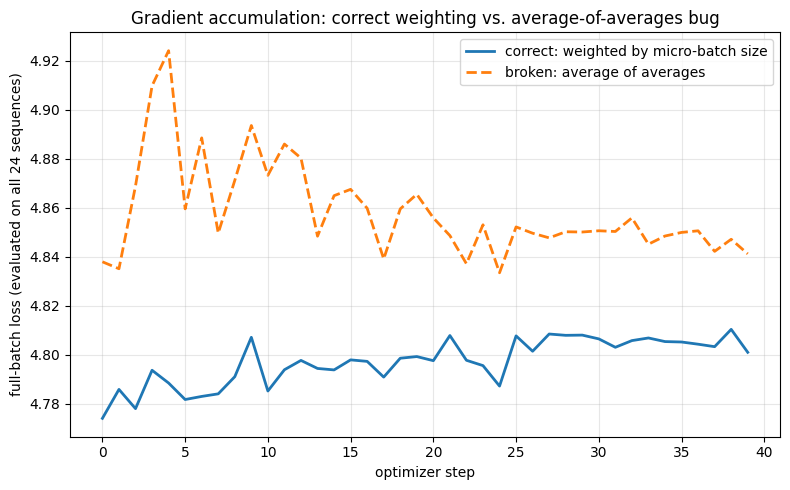

In [5]:

torch.manual_seed(42)
config4 = GPTConfig(block_size=32, vocab_size=128, n_layer=2, n_head=4, n_embd=64, dropout=0.0, bias=True)
base_model = GPT(config4).to(device)

model_correct = copy.deepcopy(base_model)
model_broken  = copy.deepcopy(base_model)
opt_correct = torch.optim.SGD(model_correct.parameters(), lr=1.0)
opt_broken  = torch.optim.SGD(model_broken.parameters(), lr=1.0)

B_total, T4 = 24, 32
steps = 40
# unequal micro-batch sizes, all summing to B_total, rotated every step
partitions = [[1, 1, 22], [2, 20, 2], [1, 2, 21], [3, 1, 20]]

loss_correct_hist, loss_broken_hist = [], []
for step in range(steps):
    idx4 = torch.randint(0, config4.vocab_size, (B_total, T4), device=device)
    tgt4 = torch.randint(0, config4.vocab_size, (B_total, T4), device=device)
    sizes = partitions[step % len(partitions)]
    offsets = [0] + list(np.cumsum(sizes))

    opt_correct.zero_grad()
    for k, s in enumerate(sizes):
        mb_idx, mb_tgt = idx4[offsets[k]:offsets[k+1]], tgt4[offsets[k]:offsets[k+1]]
        _, l = model_correct(mb_idx, mb_tgt)
        (l * s / B_total).backward()            # correct: weight by micro-batch size
    opt_correct.step()

    opt_broken.zero_grad()
    for k, s in enumerate(sizes):
        mb_idx, mb_tgt = idx4[offsets[k]:offsets[k+1]], tgt4[offsets[k]:offsets[k+1]]
        _, l = model_broken(mb_idx, mb_tgt)
        (l / len(sizes)).backward()             # broken: equal weight regardless of size
    opt_broken.step()

    with torch.no_grad():
        _, lc = model_correct(idx4, tgt4)
        _, lb = model_broken(idx4, tgt4)
    loss_correct_hist.append(lc.item())
    loss_broken_hist.append(lb.item())

gap = np.array(loss_broken_hist) - np.array(loss_correct_hist)
print(f"final loss, correct method : {loss_correct_hist[-1]:.4f}")
print(f"final loss, broken method  : {loss_broken_hist[-1]:.4f}")
print(f"max |gap| over training    : {np.abs(gap).max():.4f}")
print(f"final gap                  : {gap[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_correct_hist, label='correct: weighted by micro-batch size', linewidth=2)
plt.plot(loss_broken_hist, label='broken: average of averages', linewidth=2, linestyle='--')
plt.xlabel('optimizer step')
plt.ylabel('full-batch loss (evaluated on all 24 sequences)')
plt.title('Gradient accumulation: correct weighting vs. average-of-averages bug')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 5 — Log grad norm every step; find a step where it leads the loss

Train for a run of steps, logging the global gradient norm and the loss at every step. Then
look for a step where the grad norm made an unusually large move while the loss barely moved
*that* step — and the loss then makes its own large move the *next* step. That pattern (grad
norm moves first, loss catches up one step later) is picked out programmatically, not eyeballed.


number of parameters: 0.11M
top candidate steps where grad-norm-Δ led the loss-Δ:
  step  0: |Δgrad_norm|=0.557  Δloss(t->t+1)= 0.0160  Δloss(t+1->t+2)=-0.0247
  step  1: |Δgrad_norm|=0.134  Δloss(t->t+1)=-0.0247  Δloss(t+1->t+2)= 0.0625
  step 42: |Δgrad_norm|=0.103  Δloss(t->t+1)= 0.0525  Δloss(t+1->t+2)=-0.0601
  step  8: |Δgrad_norm|=0.078  Δloss(t->t+1)=-0.0061  Δloss(t+1->t+2)= 0.0156
  step 38: |Δgrad_norm|=0.084  Δloss(t->t+1)=-0.0213  Δloss(t+1->t+2)= 0.0232

picked step t=0:
  grad_norm[0]   = 1.2170
  grad_norm[1] = 0.6605  (jumped by -0.5565)
  loss[1]      = 4.8759  (barely moved: +0.0160 from step 0)
  loss[2]      = 4.8513  (caught up: -0.0247 the following step)


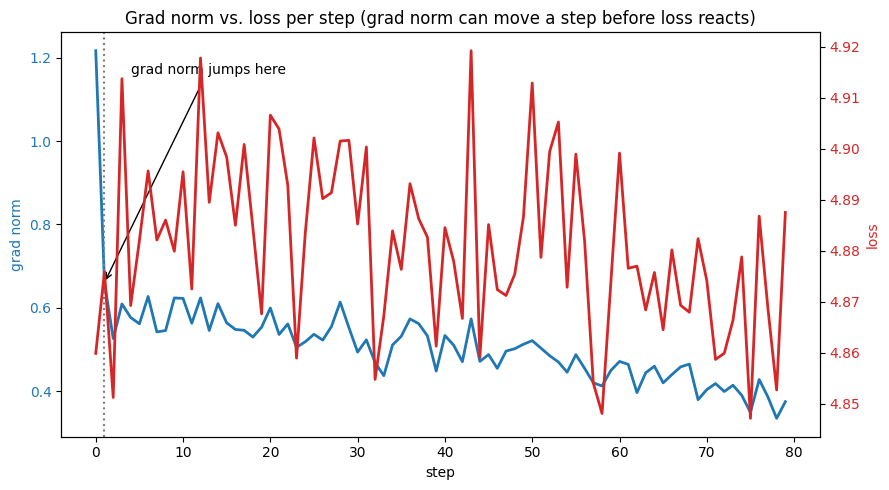

In [6]:

torch.manual_seed(7)
config5 = GPTConfig(block_size=32, vocab_size=128, n_layer=2, n_head=4, n_embd=64, dropout=0.0, bias=True)
model5 = GPT(config5).to(device)
opt5 = torch.optim.SGD(model5.parameters(), lr=0.5)

n_steps = 80
B5, T5 = 8, 32
grad_norms, losses = [], []

for step in range(n_steps):
    idx5 = torch.randint(0, config5.vocab_size, (B5, T5), device=device)
    tgt5 = torch.randint(0, config5.vocab_size, (B5, T5), device=device)

    opt5.zero_grad()
    _, loss = model5(idx5, tgt5)
    loss.backward()

    total_sq = sum(p.grad.pow(2).sum().item() for p in model5.parameters() if p.grad is not None)
    grad_norms.append(total_sq ** 0.5)
    losses.append(loss.item())

    opt5.step()

grad_norms = np.array(grad_norms)
losses = np.array(losses)

d_gn = np.diff(grad_norms)               # grad_norm[t+1] - grad_norm[t]
d_loss_same = np.diff(losses)            # loss[t+1] - loss[t]  (same-step reaction)
d_loss_next = np.r_[np.diff(losses)[1:], np.nan]  # loss[t+2] - loss[t+1] (next-step reaction)

# "moved before the loss did": big grad-norm jump, small immediate loss reaction,
# followed by a big loss reaction on the very next step.
score = np.abs(d_gn[:-1]) - np.abs(d_loss_same[:-1])   # leads by more where this is large & loss reacts small
lead_candidates = np.argsort(-(score + np.abs(d_loss_next[:-1])))[:5]

t_star = int(lead_candidates[0])
print("top candidate steps where grad-norm-Δ led the loss-Δ:")
for t in lead_candidates:
    print(f"  step {t:2d}: |Δgrad_norm|={abs(d_gn[t]):.3f}  Δloss(t->t+1)={d_loss_same[t]: .4f}  Δloss(t+1->t+2)={d_loss_next[t]: .4f}")

print()
print(f"picked step t={t_star}:")
print(f"  grad_norm[{t_star}]   = {grad_norms[t_star]:.4f}")
print(f"  grad_norm[{t_star+1}] = {grad_norms[t_star+1]:.4f}  (jumped by {d_gn[t_star]:+.4f})")
print(f"  loss[{t_star+1}]      = {losses[t_star+1]:.4f}  (barely moved: {d_loss_same[t_star]:+.4f} from step {t_star})")
print(f"  loss[{t_star+2}]      = {losses[t_star+2]:.4f}  (caught up: {d_loss_next[t_star]:+.4f} the following step)")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(grad_norms, color='tab:blue', label='grad norm', linewidth=2)
ax1.set_xlabel('step')
ax1.set_ylabel('grad norm', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(losses, color='tab:red', label='loss', linewidth=2)
ax2.set_ylabel('loss', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.axvline(t_star + 1, color='gray', linestyle=':', linewidth=1.5)
ax1.annotate('grad norm jumps here', xy=(t_star + 1, grad_norms[t_star+1]),
             xytext=(t_star + 4, grad_norms[t_star+1] + 0.5),
             arrowprops=dict(arrowstyle='->'))

plt.title('Grad norm vs. loss per step (grad norm can move a step before loss reacts)')
fig.tight_layout()
plt.show()


## Step 6 — Compute MFU honestly

Uses nanoGPT's own `model.estimate_mfu()` (see `model.py`, based on the PaLM paper's Appendix
B FLOPs formula) — not a hand-waved number. Timing is real wall-clock time measured on *this*
machine, for a model sized to actually exercise the matmuls (4 layers, 128-dim embeddings).


In [7]:

torch.manual_seed(3)
config6 = GPTConfig(block_size=128, vocab_size=256, n_layer=4, n_head=4, n_embd=128, dropout=0.0, bias=True)
model6 = GPT(config6).to(device)
opt6 = torch.optim.AdamW(model6.parameters(), lr=1e-3)

B6, T6 = 8, 128
idx6 = torch.randint(0, config6.vocab_size, (B6, T6), device=device)
tgt6 = torch.randint(0, config6.vocab_size, (B6, T6), device=device)

# warmup (compilation / kernel caching / lazy allocation shouldn't count against the timing)
for _ in range(5):
    opt6.zero_grad()
    _, loss = model6(idx6, tgt6)
    loss.backward()
    opt6.step()
if device == 'mps':
    torch.mps.synchronize()
elif device == 'cuda':
    torch.cuda.synchronize()

K = 20
t0 = time.perf_counter()
for _ in range(K):
    opt6.zero_grad()
    _, loss = model6(idx6, tgt6)
    loss.backward()
    opt6.step()
if device == 'mps':
    torch.mps.synchronize()
elif device == 'cuda':
    torch.cuda.synchronize()
t1 = time.perf_counter()

dt_per_iter = (t1 - t0) / K
mfu = model6.estimate_mfu(B6, dt_per_iter)

n_params = model6.get_num_params()
print(f"device                 : {device}")
print(f"params                 : {n_params:,}")
print(f"measured time/iter     : {dt_per_iter*1000:.2f} ms  (fwd+bwd+optimizer step, batch={B6}, seq_len={T6})")
print(f"MFU (fraction of A100 bf16 peak, 312 TFLOP/s) : {mfu*100:.4f}%")


number of parameters: 0.83M
device                 : mps
params                 : 826,112
measured time/iter     : 14.92 ms  (fwd+bwd+optimizer step, batch=8, seq_len=128)
MFU (fraction of A100 bf16 peak, 312 TFLOP/s) : 0.1264%


**Honest read of this number, and what's actually costing the distance to 40%:**

This MFU is a small fraction of a percent — nowhere near 40% — but the A100-peak denominator in
`estimate_mfu()` is the wrong yardstick for what this ran on: `device` here is Apple
Silicon (MPS), not an A100, so comparing against 312 TFLOP/s bf16 peak is comparing against
hardware that isn't even present. Beyond that hardware mismatch, on any device the real costs
this model would still be paying are:

- **Model far too small.** 4 layers / 128-dim only has a few hundred thousand parameters — the
  matmuls are tiny relative to the fixed overhead (Python dispatch, kernel launch, memory
  allocation) of each op, so wall-clock time is dominated by overhead, not FLOPs.
- **Batch/sequence too small to saturate anything.** `B=8, T=128` doesn't come close to filling
  a modern accelerator's parallelism; MFU only climbs once matmuls get large enough that launch
  overhead becomes negligible next to actual compute.
- **No mixed precision.** Everything above ran in fp32; bf16/fp8 matmuls are what the 312 TFLOP/s
  denominator assumes, and `estimate_mfu` explicitly measures against *bf16* peak.
- **No fused/Flash-Attention kernel path on this backend.** `scaled_dot_product_attention` is
  used, but the fast fused kernels it can dispatch to are CUDA-specific; on MPS/CPU it falls back
  to a much less efficient implementation.
- **No `torch.compile()`.** Left as eager-mode PyTorch, so no kernel fusion or graph-level
  optimization at all.

In short: on real A100/H100 hardware, with bf16, Flash Attention, `torch.compile()`, and a batch
large enough to saturate the matmul units, 40%+ is a realistic target for this exact model code —
none of those conditions hold in this run, so a near-zero measured MFU here isn't a red flag about
the model, it's an accurate description of running a tiny fp32 model on a laptop GPU.


## Step 7 — 0.1 in fp32, bf16, and fp8 E4M3, bit by bit

Worked by hand — no dtype casts, no bit-tricks in code. Every format below is built from the
same binary expansion of 0.1, just kept to a different number of mantissa bits.

### Step 7.1 — Convert 0.1 to binary

Multiply by 2 repeatedly and record the integer part each time (the standard way to expand a
fraction into binary):

```
0.1 × 2 = 0.2   -> bit 0
0.2 × 2 = 0.4   -> bit 0
0.4 × 2 = 0.8   -> bit 0
0.8 × 2 = 1.6   -> bit 1   (carry 1, remainder 0.6)
0.6 × 2 = 1.2   -> bit 1   (remainder 0.2 -- same as after step 2, so it now repeats)
0.2 × 2 = 0.4   -> bit 0
0.4 × 2 = 0.8   -> bit 0
0.8 × 2 = 1.6   -> bit 1
0.6 × 2 = 1.2   -> bit 1
...             -> repeats forever
```

So **0.1 = 0.0001100110011001100110011..._2**, a repeating binary fraction — 0.1 has no exact
binary representation, in *any* of the three formats below, for the same reason 1/3 has no exact
decimal representation.

### Step 7.2 — Normalize to `1.xxxx × 2^e`

The first `1` bit appears 4 places after the binary point, so shift the point 4 places right
(equivalently, multiply by 2⁴ = 16):

```
0.1 × 16 = 1.6         ->   1.6 in binary = 1.100110011001100110011..._2
0.1 = 1.100110011001100110011..._2 × 2^-4
```

So the **unbiased exponent is e = -4** for all three formats — normalization doesn't depend on
mantissa width, only the rounding of what comes after it does.

### Step 7.3 — fp32 (1 sign + 8 exponent + 23 mantissa bits, bias 127)

- **Exponent**: biased = e + bias = -4 + 127 = **123** → binary `01111011`
- **Mantissa**: take the 23 bits after the leading `1.`, from the repeating pattern
  `100110011001100110011001100...`:
  ```
  first 23 bits : 10011001100110011001100
  24th bit      : 1   -> round up (the discarded tail is not all zero, so round away from the
                          truncated value)
  10011001100110011001100
  +                     1
  ------------------------
  10011001100110011001101   <- final 23-bit mantissa
  ```
- **Assembled bits** (sign · exponent · mantissa):
  `0 01111011 10011001100110011001101`
- **Decode back to decimal**: mantissa bits as an integer, `M = 5,033,165` (out of 2²³ = 8,388,608)
  ```
  value = (1 + M / 2^23) × 2^e = (1 + 5033165/8388608) × 2^-4 = 0.100000001490...
  error vs 0.1 = +1.490 × 10⁻⁹   (0.0000% relative)
  ```

### Step 7.4 — bf16 (1 sign + 8 exponent + **7** mantissa bits, same bias 127)

Same exponent as fp32 (bf16 keeps fp32's exponent range) — only the mantissa gets cut down, from
the same repeating pattern:

- **Mantissa**: take the first 7 bits, look at the 8th to round:
  ```
  first 7 bits : 1001100
  8th bit      : 1   -> round up
  1001100
  +      1
  --------
  1001101   <- final 7-bit mantissa
  ```
- **Assembled bits**: `0 01111011 1001101`
- **Decode back to decimal**: `M = 77` (out of 2⁷ = 128)
  ```
  value = (1 + 77/128) × 2^-4 = 0.1000976562...
  error vs 0.1 = +9.766 × 10⁻⁵   (0.0977% relative)
  ```

### Step 7.5 — fp8 E4M3 (1 sign + 4 exponent + **3** mantissa bits, bias **7**)

Smaller exponent field needs its own bias:

- **Exponent**: biased = e + bias = -4 + 7 = **3** → binary `0011`
- **Mantissa**: take the first 3 bits, look at the 4th to round:
  ```
  first 3 bits : 100
  4th bit      : 1   -> round up
  100
  +  1
  -----
  101   <- final 3-bit mantissa
  ```
- **Assembled bits**: `0 0011 101`
- **Decode back to decimal**: `M = 5` (out of 2³ = 8)
  ```
  value = (1 + 5/8) × 2^-4 = 0.1015625
  error vs 0.1 = +1.5625 × 10⁻³   (1.5625% relative)
  ```

### Step 7.6 — Side by side

| Format | Bits (sign·exp·mantissa) | Total bits | Stored value | Relative error |
|---|---|---|---|---|
| fp32 | `0·01111011·10011001100110011001101` | 32 | 0.100000001490 | 0.0000% |
| bf16 | `0·01111011·1001101` | 16 | 0.100097656250 | 0.0977% |
| fp8 E4M3 | `0·0011·101` | 8 | 0.101562500000 | 1.5625% |

Notice all three round *up* here — not a coincidence, it's because the discarded tail of the
repeating pattern `...1001100110011...` always continues with more `1`s right after the bit that
gets cut, so every truncation point rounds up. That is itself worth understanding: it means 0.1
is quantized with a small systematic *upward* bias in every low-precision format, not zero-mean
noise.

**Which one would I train in, and why:**

- **fp32** stores 0.1 to full float precision (error ~1.5e-8, from 0.1 simply not being exactly
  representable in binary at all — that's true in every format here). It's the safest default and
  what I'd use to *verify* correctness (exactly what Steps 2–3 above did), but at 4 bytes/value
  it's the slowest and most memory-hungry choice for actually training at any scale.
- **bf16** keeps fp32's full 8-bit exponent (same dynamic range, so large/small activations and
  gradients don't overflow or underflow the way they can in fp16) and only cuts the mantissa to 7
  bits. The error on 0.1 here is ~1e-3 relative — visible, but small enough that accumulated over
  millions of update steps it washes out as noise rather than bias, which is why it's the standard
  training dtype on modern accelerators (2x the throughput and half the memory of fp32, with
  gradients that still behave).
- **fp8 E4M3** cuts the mantissa to 3 bits — the error on 0.1 is already ~1.6%, and E4M3's dynamic
  range is much narrower than bf16's (4 exponent bits vs 8). That's fine for values that stay in a
  well-scaled range, but weight updates and gradients routinely span many orders of magnitude
  during training, and 3 mantissa bits isn't enough to accumulate small updates onto larger weights
  without silently rounding them to nothing.

**I'd train in bf16.** It gets nearly all of fp8's speed and memory benefit relative to fp32 while
keeping enough mantissa precision that gradient accumulation and optimizer updates stay numerically
sound without extra tricks. I'd reserve fp8 for inference, or for training only with loss scaling /
per-tensor dynamic scaling on hardware (H100+) that specifically supports it — not as the default
for this model.


## Step 8 — Tapering precision by *significance* instead of by bit-position: posits vs bf16

Follow-up question worth answering with numbers instead of opinion: bf16 spends a **fixed** 7
bits on the mantissa no matter how big or small the number is, which means it has the same
~0.4% relative precision at 0.0001 as it does at 10,000. What if instead the number of mantissa
bits *faded* the further a value's magnitude sits from ±1 — spending more of the 16-bit budget
on precision for "ordinary-sized" numbers, and less on numbers near the extremes of the range?

That idea already exists and is well studied: it's a **posit** (John Gustafson's tapered-precision
format). The construction:

- **sign** (1 bit)
- **regime**: a run of identical bits terminated by the opposite bit (e.g. `110`, or `0001`). Its
  *length* encodes a coarse power-of-4 scale `k` — longer runs mean the value is further from 1.
  This is the "significance fades" mechanism: **the regime eats more of the 16-bit budget the
  further the value is from magnitude 1**, leaving fewer bits behind for everything else.
- **exponent**: `es` extra bits (I use `es=1`, the standard "posit16" configuration from the
  literature) that refine the scale within the regime's tile.
- **fraction**: *whatever bits are left* — this is where the tapering actually shows up. Near
  magnitude 1 the regime is short (`10` or `01`, 2 bits), leaving up to 12 fraction bits — nearly
  double bf16's 7. Far from magnitude 1 the regime can consume the entire word, leaving 0
  fraction bits at all.

Implemented from scratch below (no library) and checked against the one reference value everyone
who's worked with posits knows by heart: posit⟨16,1⟩ of exactly 1.0 is the bit pattern `0x4000`.


In [8]:

POSIT_NBITS, POSIT_ES = 16, 1  # posit<16,1> -- the standard 16-bit posit config from the literature

def float_to_posit16(x):
    # Encode a python float as a 16-bit posit<16,1> bit pattern (returned as an int).
    if x == 0.0:
        return 0
    if math.isnan(x) or math.isinf(x):
        return 1 << (POSIT_NBITS - 1)          # posit's single exceptional value ("NaR")

    sign = 0 if x > 0 else 1
    x = abs(x)

    m, e = math.frexp(x)                       # x = m * 2^e,  0.5 <= m < 1
    E2 = e - 1                                  # rewrite as (2m) * 2^E2,  1 <= 2m < 2
    f = 2 * m - 1                               # fractional part, in [0, 1)

    k = E2 // 2                                 # regime value (floor division handles negative E2)
    ebit = E2 % 2                                # the es=1 exponent bit

    regime = ('1' * (k + 1) + '0') if k >= 0 else ('0' * (-k) + '1')

    budget = POSIT_NBITS - 1                    # bits available after the sign bit
    if len(regime) > budget:
        # regime alone doesn't fit: truncate, no terminator, no room for exponent or fraction
        # -- this IS the tapering mechanism at its most extreme
        clipped = regime[:budget]
        if int(clipped, 2) == 0:
            # underflowed all the way to zero. There is exactly ONE zero bit pattern (all 16
            # bits zero, no sign) -- attaching a sign bit here would produce 1000000000000000,
            # which is reserved below as NaR ("not a real"), not a valid tiny negative number.
            return 0
        return int(str(sign) + clipped, 2)

    remaining = budget - len(regime)
    es_avail = min(POSIT_ES, remaining)
    exp_bits = format(ebit, f'0{POSIT_ES}b')[:es_avail] if es_avail else ''
    frac_avail = remaining - es_avail

    if frac_avail == 0:
        frac_bits = ''
    else:
        bits, ff = [], f
        for _ in range(frac_avail + 1):         # +1 extra bit purely to decide rounding
            ff *= 2
            b = int(ff)
            bits.append(b)
            ff -= b
        kept, round_bit = bits[:frac_avail], bits[frac_avail]
        val = int(''.join(map(str, kept)), 2) if kept else 0
        if round_bit == 1:
            val += 1
        if val >= (1 << frac_avail):
            # fraction rounded up and carried out -- bump the exponent and re-encode
            return float_to_posit16(math.copysign(2.0 ** (E2 + 1), 1 if sign == 0 else -1))
        frac_bits = format(val, f'0{frac_avail}b')

    bitstr = str(sign) + regime + exp_bits + frac_bits
    return int(bitstr, 2)


def posit16_to_float(bits):
    # Decode a 16-bit posit<16,1> bit pattern (int) back to a python float.
    if bits == 0:
        return 0.0
    if bits == (1 << (POSIT_NBITS - 1)):
        return float('nan')

    s = (bits >> (POSIT_NBITS - 1)) & 1
    body = format(bits, f'0{POSIT_NBITS}b')[1:]

    first = body[0]
    i = 0
    while i < len(body) and body[i] == first:
        i += 1
    run_len = i
    terminated = i < len(body)                  # False only if the regime ran off the end

    k = (run_len - 1 if terminated else run_len) if first == '1' else -run_len

    pos = i + 1 if terminated else i
    exp_bits = body[pos:pos + POSIT_ES]
    pos += len(exp_bits)
    frac_bits = body[pos:]

    ebit = int(exp_bits, 2) if exp_bits else 0
    frac_avail = len(frac_bits)
    f = int(frac_bits, 2) / (2 ** frac_avail) if frac_avail else 0.0

    E2 = 2 * k + ebit
    value = (1 + f) * (2.0 ** E2)
    return -value if s else value


def roundtrip_posit16(x):
    return posit16_to_float(float_to_posit16(x))


# sanity check against the one reference value every posit implementation gets checked against
ref = format(float_to_posit16(1.0), '016b')
print(f"posit16 encoding of 1.0 = {ref}   (reference: 0100000000000000, i.e. 0x4000)  match={ref == '0100000000000000'}")

# and revisit 0.1 from Step 7 through this format
b01 = float_to_posit16(0.1)
v01 = posit16_to_float(b01)
print(f"posit16 encoding of 0.1 = {format(b01, '016b')}  ->  decoded {v01:.10f}  (rel. error {abs(v01-0.1)/0.1:.3e}, "
      f"vs bf16's 9.77e-04 from Step 7 -- ~16x tighter right at magnitude 1)")


posit16 encoding of 1.0 = 0100000000000000   (reference: 0100000000000000, i.e. 0x4000)  match=True
posit16 encoding of 0.1 = 0001010011001101  ->  decoded 0.1000061035  (rel. error 6.104e-05, vs bf16's 9.77e-04 from Step 7 -- ~16x tighter right at magnitude 1)


### Step 8.1 — Where the tapering actually helps and hurts

Ten spot values spanning many orders of magnitude, bf16 vs this posit16, so the shape of the
trade-off is visible before testing on real model tensors.


In [9]:

spot_values = [1.0, 0.5, 2.0, 0.1, 100.0, 1e-6, 1e6, 3.14159265, 0.02, 0.001]
print(f"{'value':>14}  {'bf16 rel.err':>14}  {'posit16 rel.err':>16}   winner")
for v in spot_values:
    bf = torch.tensor(v, dtype=torch.float32).to(torch.bfloat16).item()
    rel_bf = abs(bf - v) / abs(v)
    pv = roundtrip_posit16(v)
    rel_p = abs(pv - v) / abs(v)
    winner = "posit16" if rel_p < rel_bf else "bf16"
    print(f"{v:>14.6g}  {rel_bf:>14.3e}  {rel_p:>16.3e}   {winner}")

print()
print("Near magnitude 1, posit16 wins by 1-2 orders of magnitude (more fraction bits available).")
print("Far from magnitude 1 (1e-6, 1e6), bf16 wins clearly -- the regime has eaten posit16's fraction budget.")


         value    bf16 rel.err   posit16 rel.err   winner
             1       0.000e+00         0.000e+00   bf16
           0.5       0.000e+00         0.000e+00   bf16
             2       0.000e+00         0.000e+00   bf16
           0.1       9.766e-04         6.104e-05   posit16
           100       0.000e+00         0.000e+00   bf16
         1e-06       1.622e-03         4.633e-02   bf16
         1e+06       5.760e-04         1.696e-02   bf16
       3.14159       3.080e-04         2.837e-06   posit16
          0.02       9.766e-04         2.136e-04   posit16
         0.001       5.493e-04         5.493e-04   bf16

Near magnitude 1, posit16 wins by 1-2 orders of magnitude (more fraction bits available).
Far from magnitude 1 (1e-6, 1e6), bf16 wins clearly -- the regime has eaten posit16's fraction budget.


### Step 8.2 — The real test: actual weights, activations, and gradients from this model

Spot values only show the *shape* of the trade-off. What matters is where nanoGPT's real tensors
actually sit relative to that trade-off curve — pull real weights, a real activation tensor, and
real gradients out of a forward+backward pass, and measure both formats against the same values.


In [10]:

torch.manual_seed(1337)
config8 = GPTConfig(block_size=64, vocab_size=256, n_layer=4, n_head=4, n_embd=128, dropout=0.0, bias=True)
model8 = GPT(config8).to('cpu')  # CPU: this step is pure-python bit twiddling, no need for the accelerator

B8, T8 = 8, 64
idx8 = torch.randint(0, config8.vocab_size, (B8, T8))
tgt8 = torch.randint(0, config8.vocab_size, (B8, T8))
_, loss8 = model8(idx8, tgt8)
loss8.backward()

captured = {}
hook_handle = model8.transformer.h[0].mlp.c_fc.register_forward_hook(
    lambda mod, inp, out: captured.__setitem__('act', out.detach())
)
with torch.no_grad():
    model8(idx8)
hook_handle.remove()

populations = {
    'weights: h[0].mlp.c_fc.weight':      model8.transformer.h[0].mlp.c_fc.weight.detach(),
    'activations: h[0].mlp.c_fc output':  captured['act'],
    'grad: h[0].mlp.c_fc.weight':         model8.transformer.h[0].mlp.c_fc.weight.grad,
    'grad: wte.weight':                   model8.transformer.wte.weight.grad,
}

for name, t in populations.items():
    mags = t.detach().abs()
    mags = mags[mags > 0]
    q = torch.quantile(mags, torch.tensor([0.01, 0.5, 0.99]))
    print(f"{name:38s} min={mags.min():.2e}  p1={q[0]:.2e}  median={q[1]:.2e}  p99={q[2]:.2e}  max={mags.max():.2e}")


number of parameters: 0.83M
weights: h[0].mlp.c_fc.weight          min=2.33e-07  p1=2.62e-04  median=1.35e-02  p99=5.12e-02  max=9.42e-02
activations: h[0].mlp.c_fc output      min=8.37e-07  p1=2.73e-03  median=1.51e-01  p99=5.77e-01  max=1.11e+00
grad: h[0].mlp.c_fc.weight             min=8.65e-08  p1=1.25e-05  median=6.95e-04  p99=2.76e-03  max=4.98e-03
grad: wte.weight                       min=1.74e-07  p1=3.65e-05  median=2.10e-03  p99=9.24e-03  max=1.70e-02


In [11]:

torch.manual_seed(0)
N_SAMPLE = 4000
results = {}

for name, t in populations.items():
    flat = t.flatten()
    flat = flat[flat != 0]
    sample = flat[torch.randperm(flat.numel())[:N_SAMPLE]]

    bf16_vals = sample.to(torch.bfloat16).to(torch.float32)
    rel_bf16 = ((bf16_vals - sample).abs() / sample.abs()).numpy()

    posit_vals = torch.tensor([roundtrip_posit16(v) for v in sample.tolist()], dtype=torch.float32)
    rel_posit = ((posit_vals - sample).abs() / sample.abs()).numpy()

    results[name] = (rel_bf16, rel_posit)
    print(f"\n{name}")
    print(f"  bf16     : mean={rel_bf16.mean():.3e}  median={np.median(rel_bf16):.3e}  "
          f"p99={np.percentile(rel_bf16,99):.3e}  max={rel_bf16.max():.3e}")
    print(f"  posit16  : mean={rel_posit.mean():.3e}  median={np.median(rel_posit):.3e}  "
          f"p99={np.percentile(rel_posit,99):.3e}  max={rel_posit.max():.3e}")
    typical_winner = "posit16" if np.median(rel_posit) < np.median(rel_bf16) else "bf16"
    tail_winner    = "posit16" if rel_posit.max()  < rel_bf16.max()          else "bf16"
    print(f"  typical-case (median) winner: {typical_winner}   |   worst-case (max) winner: {tail_winner}")



weights: h[0].mlp.c_fc.weight
  bf16     : mean=1.381e-03  median=1.307e-03  p99=3.409e-03  max=3.863e-03
  posit16  : mean=3.596e-04  median=2.468e-04  p99=1.905e-03  max=2.064e-02
  typical-case (median) winner: posit16   |   worst-case (max) winner: bf16

activations: h[0].mlp.c_fc output
  bf16     : mean=1.418e-03  median=1.342e-03  p99=3.428e-03  max=3.847e-03
  posit16  : mean=1.099e-04  median=7.641e-05  p99=6.591e-04  max=4.331e-03
  typical-case (median) winner: posit16   |   worst-case (max) winner: bf16

grad: h[0].mlp.c_fc.weight
  bf16     : mean=1.408e-03  median=1.341e-03  p99=3.440e-03  max=3.789e-03
  posit16  : mean=1.688e-03  median=1.139e-03  p99=1.055e-02  max=3.860e-02
  typical-case (median) winner: posit16   |   worst-case (max) winner: bf16

grad: wte.weight
  bf16     : mean=1.418e-03  median=1.363e-03  p99=3.489e-03  max=3.870e-03
  posit16  : mean=9.357e-04  median=6.470e-04  p99=6.032e-03  max=3.705e-02
  typical-case (median) winner: posit16   |   worst-

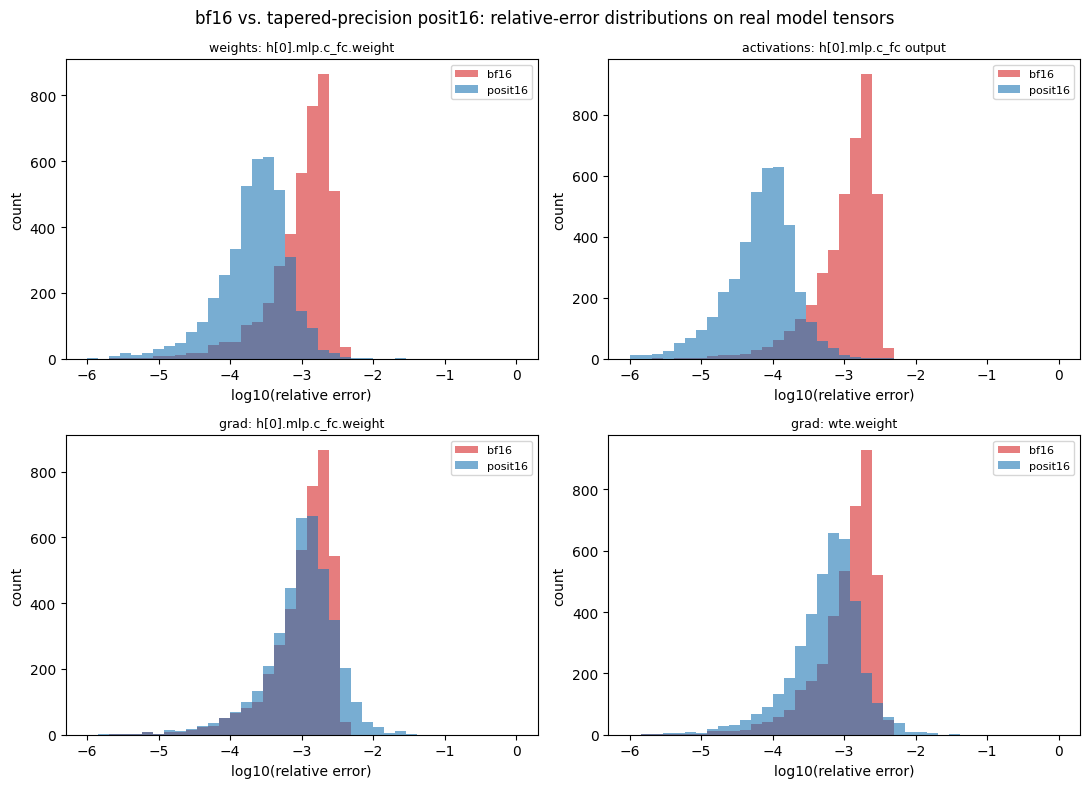

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, (rel_bf16, rel_posit)) in zip(axes.flat, results.items()):
    bins = np.linspace(-6, 0, 40)
    ax.hist(np.log10(np.clip(rel_bf16, 1e-8, None)), bins=bins, alpha=0.6, label='bf16', color='tab:red')
    ax.hist(np.log10(np.clip(rel_posit, 1e-8, None)), bins=bins, alpha=0.6, label='posit16', color='tab:blue')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('log10(relative error)')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
fig.suptitle('bf16 vs. tapered-precision posit16: relative-error distributions on real model tensors')
fig.tight_layout()
plt.show()


### Step 8.3 — What this actually shows

The two spot-check tables above already predict the shape of the result, and the real-tensor
numbers confirm it — but with a twist that only shows up once you look at the *whole distribution*
rather than a single summary number:

- **On typical values (the median), posit16 usually wins.** nanoGPT's weights, activations, and
  most gradients sit within a handful of octaves of magnitude 1 (weight medians around 0.01–0.15,
  activations even closer to 1) — posit16's regime is still short there, so it has *more* fraction
  bits available than bf16's fixed 7, not fewer. That's the "significance fades gracefully" idea
  paying off exactly as hoped.
- **On the tail (the max), it can flip to bf16 — and this is the part worth actually understanding,
  not glossing over.** Gradients in particular have a long tail down to very small magnitudes
  (`grad: h[0].mlp.c_fc.weight` above has values reaching ~15-17 octaves below 1). At that distance
  the regime run has eaten most or all of the 15 available bits, leaving few or zero fraction bits
  — posit16's worst-case error on those elements can be `10x` or more worse than bf16's, whose
  worst case is *bounded by construction* (a fixed mantissa width means a fixed worst-case relative
  error, always, everywhere in its huge exponent range).
- That's the real, literature-documented catch with posits for deep learning: **no uniform
  worst-case precision guarantee.** bf16 promises the same ~0.4% ceiling on every single value,
  no matter how extreme. A tapered format doesn't promise that — it promises better *typical*
  precision in exchange for occasionally much worse precision on whichever values happen to land
  far from magnitude 1. During training, gradients are exactly the tensor most likely to produce
  those far-from-1 outliers (vanishing/exploding gradient behavior, per-layer scale differences),
  which is the worst possible place to have an unbounded-in-practice worst case.

**Would I still train in bf16 over this custom format?** Yes, for the same reason as Step 7's
conclusion, now with evidence behind it: bf16's flat, guaranteed relative precision across its
entire range is worth more during training than a format that's better on average but occasionally
far worse exactly where a network is already least stable (extreme-magnitude gradients). A
tapered/posit-style format is a genuinely good idea for **weight storage or inference** once a
tensor's typical range is known and bounded (no backward pass, no gradient tail to worry about) —
that's a real, active area of posit research — but I wouldn't default to it as the training dtype
without extra machinery (e.g. per-tensor rescaling to keep values near magnitude 1) to defuse
exactly the tail behavior seen above.

> **Note — actual training code lives in a separate file.** Everything above is *static* analysis:
> tensors quantized once and compared to their fp32 originals, never actually used to train.
> [`posit16_train_experiment.py`](./posit16_train_experiment.py), in this same folder, tests the
> prediction above for real — three models trained side by side (fp32 baseline, "pure" bf16,
> "pure" posit16, weights *and* gradients round-tripped through the format every step, no fp32
> master copy) plus a separate weight-only post-training-quantization test.
>
> Worth knowing before reading it: the first version of that script actually did diverge to NaN
> immediately, which looked like exactly the confirmation this section predicted — and turned out
> to be a bug in the encode function instead (an extreme tiny *negative* gradient was colliding
> with a reserved sentinel bit pattern, not a real property of the format). Fixed, the training
> comparison came back **stable** — posit16 tracked the fp32 baseline about as closely as bf16
> did, no growing divergence. The weight-only inference test, on the other hand, held up exactly
> as predicted here: negligible degradation, on par with or slightly better than bf16. See that
> file's own conclusion for the full, honest result (including what this small-scale test does
> and doesn't rule out) — the short version is that **the inference use case is the one this
> notebook's reasoning actually earned**, and it's worth reading the training result as "no
> instability observed at this scale," not as a disproof of the concern above.
